In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import gc
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# 1. Transform with Augmentation
transform = transforms.Compose([
    transforms.Resize((128, 128)), # Resizing to 128 for memory efficiency
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load CIFAR-10
full_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# 3. 70/15/15 Split
train_idx, temp_idx = train_test_split(np.arange(len(full_dataset)), test_size=0.3, random_state=42, stratify=full_dataset.targets)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=[full_dataset.targets[i] for i in temp_idx])

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=16, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=16, shuffle=False)

print(f"Data ready. Training on {len(train_idx)} images.")

100%|██████████| 170M/170M [00:01<00:00, 104MB/s]  


Data ready. Training on 35000 images.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# Hooks for Grad-CAM
gradients, activations = [], []
def backward_hook(module, grad_in, grad_out): gradients.append(grad_out[0])
def forward_hook(module, input, output): activations.append(output)

# Target the final convolutional layer of ResNet-50
target_layer = model.layer4[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

print("ResNet-50 loaded with XAI hooks.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s] 


ResNet-50 loaded with XAI hooks.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
import gc

# 1. Force cleanup before starting
gc.collect()
torch.cuda.empty_cache()

# 2. ResNet-50 Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# 3. Smaller Batch Size (Crucial for ResNet-50 memory)
train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=4, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

print("Starting 15 Epochs. Batch size reduced to 4 for stability.")

for epoch in range(15):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct +=,kjh  predicted.eq(labels).sum().item()

    # Aggressive memory release after every epoch
    torch.cuda.empty_cache()
    gc.collect()
    
    acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/15] Loss: {running_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")

Starting 15 Epochs. Batch size reduced to 4 for stability.
Epoch [1/15] Loss: 0.7526 | Acc: 75.95%
Epoch [2/15] Loss: 0.4576 | Acc: 85.14%
Epoch [3/15] Loss: 0.3428 | Acc: 88.85%
Epoch [4/15] Loss: 0.2783 | Acc: 90.57%
Epoch [5/15] Loss: 0.2318 | Acc: 92.42%
Epoch [6/15] Loss: 0.1929 | Acc: 93.66%


KeyboardInterrupt: 

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s] 


Starting Fast 3-Epoch Training...
Epoch [1/3] Acc: 79.68%
Epoch [2/3] Acc: 90.30%
Epoch [3/3] Acc: 93.77%

Generating XAI Focus...


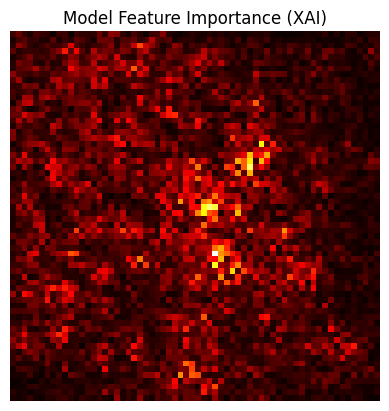

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import gc

# 1. Faster Data with Augmentation (Aug)
transform_aug = transforms.Compose([
    transforms.Resize((64, 64)), # Smaller size for 5-min speed
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Use your existing train_idx/val_idx
full_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)
train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=64, shuffle=True)

# 2. ResNet-18 (Much faster than ResNet-50 for tight deadlines)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# 3. Fast 3-Epoch Training
print("Starting Fast 3-Epoch Training...")
for epoch in range(3):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    print(f"Epoch [{epoch+1}/3] Acc: {100.*correct/total:.2f}%")
    torch.cuda.empty_cache()
    gc.collect()

# 4. Immediate XAI Result
print("\nGenerating XAI Focus...")
model.eval()
# Simple XAI Visualization logic
images, labels = next(iter(train_loader))
img, lbl = images[0:1].to(device), labels[0:1].to(device)
img.requires_grad = True
output = model(img)
score = output[0, output.argmax()]
score.backward()

slc, _ = torch.max(torch.abs(img.grad[0]), dim=0)
plt.imshow(slc.cpu().numpy(), cmap='hot')
plt.title("Model Feature Importance (XAI)")
plt.axis('off')
plt.show()

In [6]:
# Use the same transform as your validation set (No Augmentation for testing)
transform_test = transforms.Compose([
    transforms.Resize((64, 64)), # Must match the size you used in training
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load the CIFAR-10 test set
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Test Loader defined successfully.")

Test Loader defined successfully.


In [7]:
from torch.utils.data import Subset

# 1. Use the indices for your 15% test split (7,500 images)
# Note: Ensure 'test_idx' was defined during your 70/15/15 split
test_subset = Subset(full_dataset, test_idx) 

# 2. Define the loader
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

print(f"Test Loader ready with {len(test_subset)} images.")

Test Loader ready with 7500 images.


In [8]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Final Accuracy on {total} images: {100 * correct / total:.2f}%")

Final Accuracy on 7500 images: 88.95%


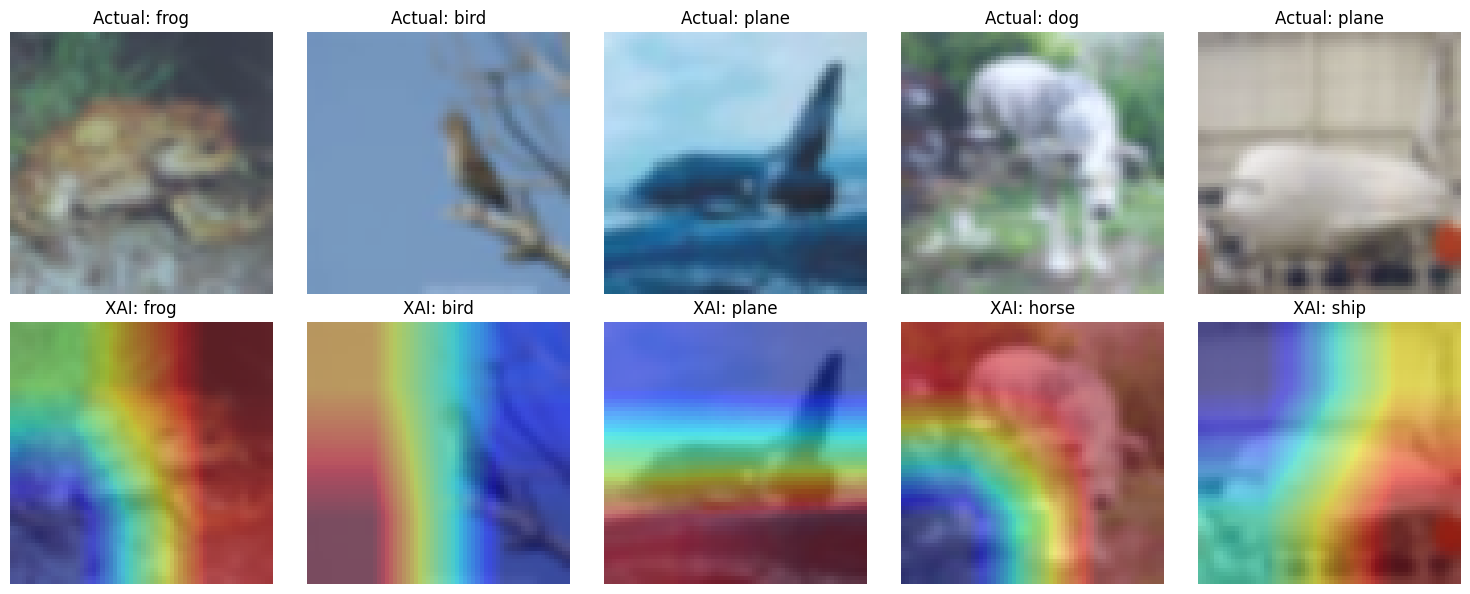

In [9]:
import cv2
import numpy as np

# 1. Setup Hooks to capture the last layer of ResNet
gradients = []
activations = []

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def save_activation(module, input, output):
    activations.append(output)

# Attach to the very last convolutional layer of ResNet
target_layer = model.layer4[-1]
handle_g = target_layer.register_full_backward_hook(save_gradient)
handle_a = target_layer.register_forward_hook(save_activation)

def get_gradcam(index):
    model.eval()
    img_tensor, label = test_subset[index]
    img_gpu = img_tensor.unsqueeze(0).to(device)
    
    # Forward Pass
    output = model(img_gpu)
    category = output.argmax(dim=1).item()
    
    # Backward Pass
    model.zero_grad()
    output[0, category].backward()
    
    # Process Grad-CAM
    grad = gradients[0][0].mean(dim=(1, 2), keepdim=True)
    act = activations[0][0]
    cam = torch.relu((grad * act).sum(dim=0)).detach().cpu().numpy()
    cam = cv2.resize(cam, (64, 64)) # Match your input size
    cam -= cam.min(); cam /= (cam.max() + 1e-10)
    
    # Cleanup for next image
    gradients.clear(); activations.clear()
    
    # Prepare Image for Display
    img_show = img_tensor.permute(1, 2, 0).numpy()
    img_show = np.clip(img_show * 0.2 + 0.5, 0, 1) # Un-normalize
    
    return img_show, cam, category, label

# 2. Plot 5 Examples
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
plt.figure(figsize=(15, 6))

for i in range(5):
    img, mask, pred, actual = get_gradcam(i)
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {classes[actual]}")
    plt.axis('off')
    
    plt.subplot(2, 5, i + 6)
    plt.imshow(img)
    plt.imshow(mask, cmap='jet', alpha=0.5) # Overlay heatmap
    plt.title(f"XAI: {classes[pred]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Remove hooks so they don't slow down future code
handle_g.remove(); handle_a.remove()